# IDS Stage 1 - Adapted for nDPI CSV Format
Détection d'anomalies sur données de flux réseau nDPI

In [34]:
# Import relevant modules
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import pickle
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import metrics, tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.feature_selection import RFE
import itertools

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Settings
pd.set_option('display.max_columns', None)
np.set_printoptions(threshold=1000)
np.set_printoptions(precision=3)
sns.set(style="darkgrid")
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

## 1. LOAD DATA

In [35]:
# Chemins vers vos datasets
TRAIN_PATH = "data/vertx_realtime_normaltraffic_20260204_3_000_000.csv"
TEST_PATH = "data/vertx_realtime_normaltraffic_20260203.csv"  # ou un autre fichier test

print("📥 Chargement des données...")
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print(f"✅ Train: {train.shape[0]} rows × {train.shape[1]} columns")
print(f"✅ Test: {test.shape[0]} rows × {test.shape[1]} columns")

📥 Chargement des données...
✅ Train: 2100808 rows × 59 columns
✅ Test: 299076 rows × 59 columns


In [36]:
# Aperçu des données
print("\n📊 Premières lignes du dataset d'entraînement:")
train.head()


📊 Premières lignes du dataset d'entraînement:


,id,flowKey,firstSeen,lastSeen,srcIp,dstIp,srcPort,dstPort,protocol,bytes,packets,packetSummaries,treatmentDelay,durationMs,reasonOfFlowEnd,minPacketLength,maxPacketLength,meanPacketLength,stddevPacketLength,bytesPerSecond,packetsPerSecond,totalBytesUpstream,totalBytesDownstream,totalPacketsUpstream,totalPacketsDownstream,ratioBytesUpDown,ratioPacketsUpDown,flowDurationMs,interArrivalTimeMean,interArrivalTimeStdDev,interArrivalTimeMin,interArrivalTimeMax,flowSymmetry,synRate,finRate,rstRate,ackRate,pshRate,synCount,finCount,rstCount,ackCount,pshCount,tcpFraction,udpFraction,otherFraction,appProtocolBytes,appProtocol,riskLevel,riskMask,riskLabel,riskSeverity,ndpiFlowPtr,srcCountry,dstCountry,srcDomain,dstDomain,srcOrg,dstOrg
0,31d017fa-322a-4034-9c54-e99fc5ca06ca,10.180.137.66_172.64.154.211_41086_443_TCP,22557-01-13 23:40:3.2480000007,22557-01-13 23:40:4.3030000000,10.180.137.66,172.64.154.211,41086.0,443.0,TCP,132,2,{'P_10.180.137.66_172.64.154.211_TCP_ACK_64966...,"{15,16}",3055,Inactivity Timeout,66,66,66.0,0.000000,43.207855,0.654664,132.0,0.0,2.0,0.0,1.000000,1.0,3055.0,3055.00000,NaN,3055.0,3055.0,0.000000,0.0,0.00,0.5,1.0,0.00,0,0,1,2,0,1.0,0.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,130660475763680,NaN,NaN,NaN,NaN,NaN,NaN
1,f892c42b-ff89-41f2-9d64-bb13932f3922,10.162.8.10_10.180.137.66_53_47045_UDP,22565-04-05 05:37:3.9130000008,22565-04-05 05:37:3.9130000008,10.162.8.10,10.180.137.66,53.0,47045.0,UDP,149,1,{'P_10.162.8.10_10.180.137.66_UDP__64992362985...,{7},0,Inactivity Timeout,149,149,149.0,NaN,0.000000,0.000000,149.0,0.0,1.0,0.0,1.000000,1.0,0.0,0.00000,0.00000,0.0,0.0,0.000000,0.0,0.00,0.0,0.0,-1.00,0,0,0,0,0,0.0,1.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,130660871555872,NaN,NaN,NaN,NaN,NaN,NaN
2,b9cf61eb-4031-414f-ac42-38fe4cc346a8,10.162.8.10_10.180.137.66_53_35096_UDP,22565-04-10 00:58:0.8140000003,22565-04-10 00:58:0.5030000006,10.180.137.66,10.162.8.10,35096.0,53.0,UDP,254,2,{'P_10.180.137.66_10.162.8.10_UDP__64992404508...,"{12,12}",2689,Inactivity Timeout,85,169,127.0,59.396970,94.458910,0.743771,85.0,169.0,1.0,1.0,0.502959,1.0,2689.0,2689.00000,NaN,2689.0,2689.0,0.502959,0.0,0.00,0.0,0.0,-1.00,0,0,0,0,0,0.0,1.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,130660062943904,NaN,NaN,NaN,NaN,NaN,NaN
3,bd08a5c3-a738-42d3-ac34-0e4cdb50cc14,10.180.137.66_140.82.114.5_40238_443_TCP,22565-11-14 08:59:4.2940000004,22565-11-14 08:59:4.5340000005,140.82.114.5,10.180.137.66,443.0,40238.0,TCP,264,4,{'P_140.82.114.5_10.180.137.66_TCP_FIN_6499429...,"{15,16,16,16}",1240,Inactivity Timeout,54,90,66.0,16.970562,212.903230,3.225807,156.0,108.0,2.0,2.0,1.444444,1.0,1240.0,413.33334,269.61887,159.0,696.0,0.692308,0.0,0.25,0.5,0.5,0.25,0,1,2,2,1,1.0,0.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,130661073369904,NaN,NaN,NaN,NaN,NaN,NaN
4,bd9d945d-4f0b-41dd-b6d7-b125ad617196,10.162.8.10_10.180.137.66_53_35068_UDP,22571-08-22 14:09:0.8060000004,22571-08-22 14:09:0.8060000004,10.162.8.10,10.180.137.66,53.0,35068.0,UDP,148,1,{'P_10.162.8.10_10.180.137.66_UDP__65012497254...,{19},0,Inactivity Timeout,148,148,148.0,NaN,0.000000,0.000000,148.0,0.0,1.0,0.0,1.000000,1.0,0.0,0.00000,0.00000,0.0,0.0,0.000000,0.0,0.00,0.0,0.0,-1.00,0,0,0,0,0,0.0,1.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,130662284939168,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
# Informations sur les colonnes
print("\n📋 Informations sur les colonnes:")
train.info()


📋 Informations sur les colonnes:
<class 'pandas.DataFrame'>
RangeIndex: 2100808 entries, 0 to 2100807
Data columns (total 59 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   id                      str    
 1   flowKey                 str    
 2   firstSeen               str    
 3   lastSeen                str    
 4   srcIp                   str    
 5   dstIp                   str    
 6   srcPort                 float64
 7   dstPort                 float64
 8   protocol                str    
 9   bytes                   int64  
 10  packets                 int64  
 11  packetSummaries         str    
 12  treatmentDelay          str    
 13  durationMs              int64  
 14  reasonOfFlowEnd         str    
 15  minPacketLength         int64  
 16  maxPacketLength         int64  
 17  meanPacketLength        float64
 18  stddevPacketLength      float64
 19  bytesPerSecond          float64
 20  packetsPerSecond        float64
 21  totalByt

## 2. FEATURE SELECTION - Features nDPI pertinentes

In [38]:
# Features numériques de base (similaires à votre config)
BASE_FEATURES = [
    'bytes', 'packets', 'minPacketLength', 'maxPacketLength',
    'meanPacketLength', 'stddevPacketLength', 'bytesPerSecond', 'packetsPerSecond',
    'totalBytesUpstream', 'totalBytesDownstream', 'totalPacketsUpstream',
    'totalPacketsDownstream', 'ratioBytesUpDown', 'ratioPacketsUpDown',
    'flowDurationMs', 'interArrivalTimeMean', 'interArrivalTimeStdDev',
    'interArrivalTimeMin', 'interArrivalTimeMax', 'flowSymmetry',
    'synRate', 'finRate', 'rstRate', 'ackRate', 'pshRate',
    'synCount', 'finCount', 'rstCount', 'ackCount', 'pshCount',
    'tcpFraction', 'udpFraction', 'otherFraction'
]

# Features dérivées (calculées plus tard)
DERIVED_FEATURES = [
    'avgPacketIntervalMs',
    'synFinDiff',
    'ackRatePerMs',
    'iatMaxToMeanRatio'
]

# Colonnes à supprimer (non pertinentes pour la détection)
COLUMNS_TO_DROP = [
    'id', 'flowKey', 'firstSeen', 'lastSeen', 'srcIp', 'dstIp',
    'srcPort', 'dstPort', 'packetSummaries', 'treatmentDelay',
    'reasonOfFlowEnd', 'appProtocolBytes', 'appProtocol',
    'riskLevel', 'riskMask', 'riskLabel', 'riskSeverity',
    'ndpiFlowPtr', 'srcCountry', 'dstCountry', 'srcDomain',
    'dstDomain', 'srcOrg', 'dstOrg', "durationMs"
]

ALL_FEATURES = BASE_FEATURES + DERIVED_FEATURES

print(f"✅ {len(BASE_FEATURES)} features de base sélectionnées")
print(f"✅ {len(DERIVED_FEATURES)} features dérivées à calculer")

✅ 33 features de base sélectionnées
✅ 4 features dérivées à calculer


## 3. DATA PREPROCESSING

In [39]:
def preprocess_ndpi_data(df, is_train=True):
    """
    Prétraitement des données nDPI
    """
    df = df.copy()
    
    print(f"\n🧹 Preprocessing {'TRAIN' if is_train else 'TEST'} data...")
    print(f"   Initial shape: {df.shape}")
    
    # 1. Convertir les features numériques
    for col in BASE_FEATURES:
        if col not in df.columns:
            print(f"   ⚠️ Missing feature: {col} (set to 0)")
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # 2. Nettoyer les valeurs infinies et NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # 3. Remplacer 0 par 1 pour éviter divisions par zéro
    cols_to_replace = ['flowDurationMs', 'totalPacketsUpstream', 
                       'totalPacketsDownstream', 'interArrivalTimeMean']
    for col in cols_to_replace:
        if col in df.columns:
            df[col] = df[col].replace(0, 1)
    
    # 4. Calculer les features dérivées
    df['avgPacketIntervalMs'] = df['flowDurationMs'] / (
        df['totalPacketsUpstream'] + df['totalPacketsDownstream'] + 1e-6
    )
    df['synFinDiff'] = df['synCount'] - df['finCount']
    df['ackRatePerMs'] = df['ackCount'] / (df['flowDurationMs'] + 1e-6)
    df['iatMaxToMeanRatio'] = df['interArrivalTimeMax'] / (
        df['interArrivalTimeMean'] + 1e-6
    )
    
    # 5. Remplir les NaN restants
    df.fillna(0, inplace=True)
    
    # 🔥 NOUVEAU : Supprimer les colonnes inutiles
    cols_to_drop = [col for col in COLUMNS_TO_DROP if col in df.columns]
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)
        print(f"   🗑️ Suppression de {len(cols_to_drop)} colonnes inutiles")
    
    # 6. Créer/extraire le label si disponible
    if 'label' in df.columns:
        df['class'] = df['label']
    elif 'attackType' in df.columns:
        df['class'] = df['attackType']
    elif 'riskLabel' in df.columns:
        df['class'] = df['riskLabel'].apply(
            lambda x: 'normal' if 'No risk' in str(x) else 'anomaly'
        )
    else:
        if is_train:
            df['class'] = 'normal'
    
    print(f"   ✅ Final shape: {df.shape}")
    print(f"   ✅ Features: {len(BASE_FEATURES + DERIVED_FEATURES)}")
    
    return df

# Appliquer le preprocessing
train_processed = preprocess_ndpi_data(train, is_train=True)
test_processed = preprocess_ndpi_data(test, is_train=False)


🧹 Preprocessing TRAIN data...
   Initial shape: (2100808, 59)
   🗑️ Suppression de 25 colonnes inutiles
   ✅ Final shape: (2100808, 39)
   ✅ Features: 37

🧹 Preprocessing TEST data...
   Initial shape: (299076, 59)
   🗑️ Suppression de 25 colonnes inutiles
   ✅ Final shape: (299076, 38)
   ✅ Features: 37


In [40]:
# Vérifier la distribution des classes (si labels disponibles)
if 'class' in train_processed.columns:
    print("\n📊 Distribution des classes dans le train set:")
    print(train_processed['class'].value_counts())
    print(f"\nProportions:")
    print(train_processed['class'].value_counts(normalize=True))


📊 Distribution des classes dans le train set:
class
normal    2100808
Name: count, dtype: int64

Proportions:
class
normal    1.0
Name: proportion, dtype: float64


## 4. EXPLORATORY ANALYSIS

In [41]:
# Statistiques descriptives
print("\n📊 Statistiques descriptives des features principales:")
main_features = ['bytes', 'packets', 'flowDurationMs', 'bytesPerSecond', 
                'packetsPerSecond', 'synCount', 'finCount', 'ackCount']
train_processed[main_features].describe()


📊 Statistiques descriptives des features principales:


,bytes,packets,flowDurationMs,bytesPerSecond,packetsPerSecond,synCount,finCount,ackCount
count,2.100808e+06,2.100808e+06,2.100808e+06,2.100808e+06,2.100808e+06,2.100808e+06,2.100808e+06,2.100808e+06
mean,7.340516e+03,1.680254e+00,3.156964e+04,8.099639e+02,2.760866e-01,1.943586e-02,1.652412e-02,1.517784e+00
std,9.779544e+03,1.442412e+00,5.128278e+05,2.409478e+04,6.268234e+00,1.523853e-01,1.558460e-01,1.520552e+00
min,4.200000e+01,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.830000e+02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
50%,5.858000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,7.372000e+03,2.000000e+00,3.973000e+03,6.076123e+02,3.514527e-01,0.000000e+00,0.000000e+00,2.000000e+00
max,2.003520e+05,9.900000e+01,8.380118e+07,1.527000e+07,2.000000e+03,2.000000e+00,3.000000e+00,9.900000e+01


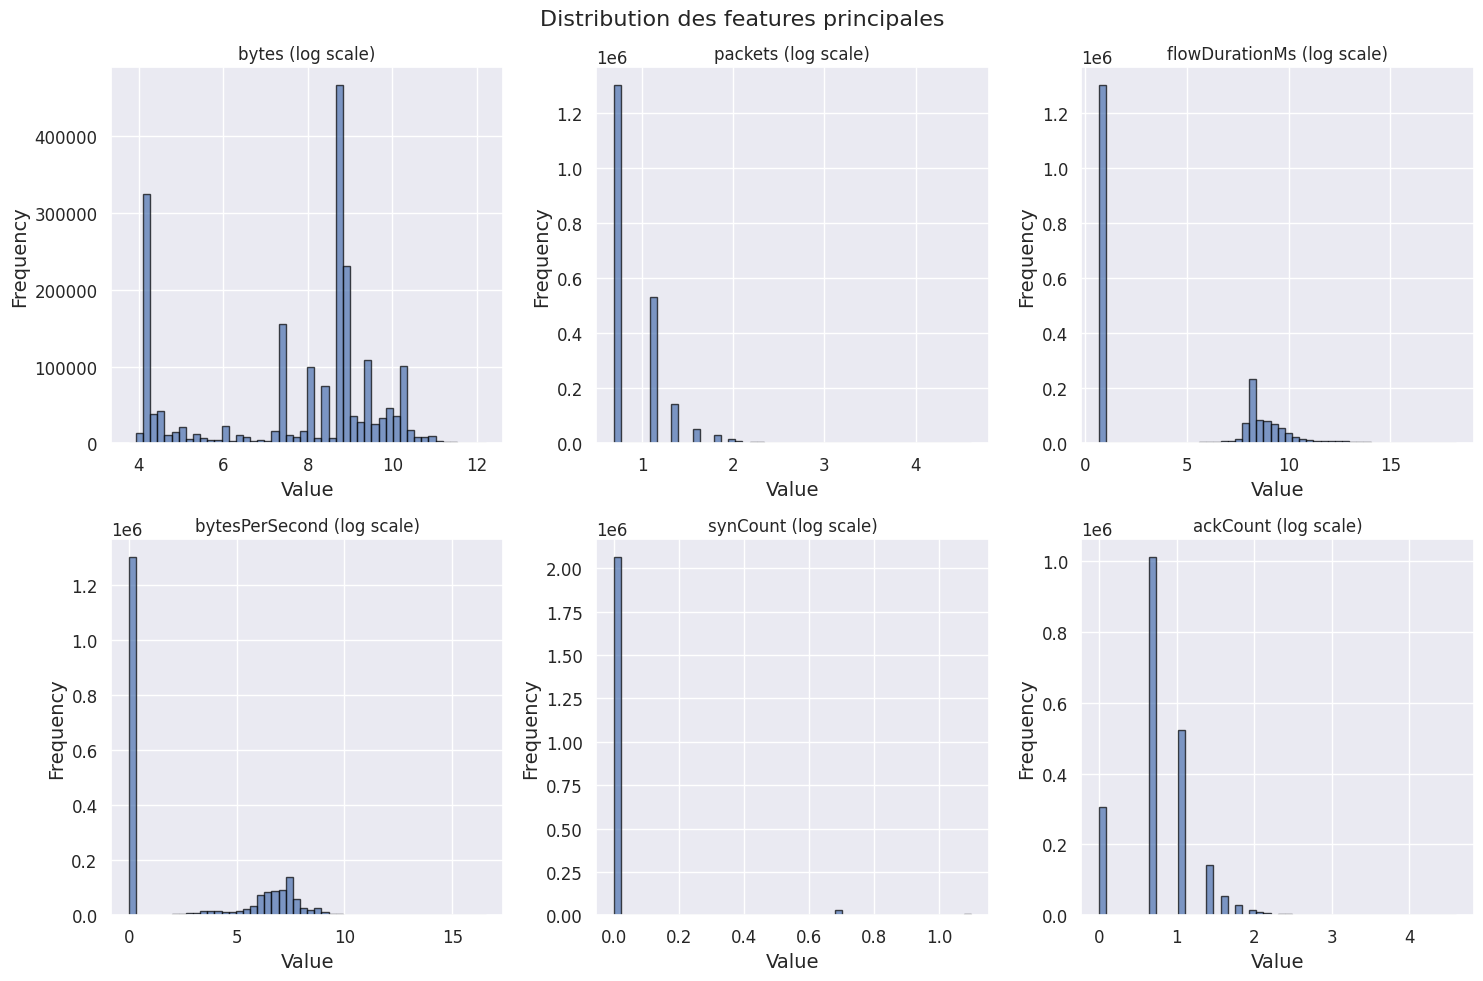

In [42]:
# Visualisation de quelques distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution des features principales', fontsize=16)

features_to_plot = ['bytes', 'packets', 'flowDurationMs', 
                    'bytesPerSecond', 'synCount', 'ackCount']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    # Log transform pour meilleure visualisation
    data = np.log1p(train_processed[feature])
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'{feature} (log scale)')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [43]:
# 🔍 DEBUG : Analyse du test set
print("\n" + "="*80)
print("🔍 ANALYSE DU TEST SET")
print("="*80)

if 'riskLabel' in test_processed.columns:
    print("\n📊 Distribution riskLabel dans test :")
    print(test_processed['riskLabel'].value_counts())
    
if 'attackType' in test_processed.columns:
    print("\n📊 Distribution attackType dans test :")
    print(test_processed['attackType'].value_counts())

print(f"\n📊 Statistiques test vs train :")
print(f"   Train flows : {len(train_processed)}")
print(f"   Test flows  : {len(test_processed)}")
print(f"   Ratio       : {len(test_processed) / len(train_processed):.1f}x")

# Comparer les distributions
print(f"\n📊 Moyennes des features (Test vs Train) :")
for col in ['bytes', 'packets', 'flowDurationMs'][:3]:
    train_mean = train_processed[col].mean()
    test_mean = test_processed[col].mean()
    diff_pct = abs(test_mean - train_mean) / train_mean * 100
    print(f"   {col:20s} : Train={train_mean:>10.2f}  Test={test_mean:>10.2f}  Diff={diff_pct:>6.1f}%")


🔍 ANALYSE DU TEST SET

📊 Statistiques test vs train :
   Train flows : 2100808
   Test flows  : 299076
   Ratio       : 0.1x

📊 Moyennes des features (Test vs Train) :
   bytes                : Train=   7340.52  Test=   6845.14  Diff=   6.7%
   packets              : Train=      1.68  Test=      1.66  Diff=   1.4%
   flowDurationMs       : Train=  31569.64  Test=  31508.19  Diff=   0.2%


## 5. FEATURE ENGINEERING & SCALING

In [44]:
X_train_raw = train_processed[ALL_FEATURES].copy()
X_test_raw = test_processed[ALL_FEATURES].copy()

y_train = None
y_train_encoded = None
print("\n⚠️ Pas de labels disponibles (mode non supervisé)")

y_test = None
y_test_encoded = None

print(f"\n📊 Features shape:")
print(f"   X_train: {X_train_raw.shape}")
print(f"   X_test: {X_test_raw.shape}")


⚠️ Pas de labels disponibles (mode non supervisé)

📊 Features shape:
   X_train: (2100808, 37)
   X_test: (299076, 37)


In [45]:
# Log transformation des features (comme dans votre config)
log_cols = [
    'bytes', 'packets', 'durationMs', 'meanPacketLength',
    'bytesPerSecond', 'packetsPerSecond', 'totalBytesUpstream',
    'totalBytesDownstream', 'totalPacketsUpstream', 'totalPacketsDownstream',
    'flowDurationMs', 'interArrivalTimeMean', 'interArrivalTimeStdDev',
    'avgPacketIntervalMs'
]

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

for col in log_cols:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_test[col] = np.log1p(X_test[col])

print("✅ Log transformation appliquée")

✅ Log transformation appliquée


In [46]:
# Scaling avec StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir en DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=ALL_FEATURES)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=ALL_FEATURES)

print("✅ Scaling appliqué (mean=0, std=1)")
print(f"   Train mean: {X_train_scaled.mean():.6f}")
print(f"   Train std: {X_train_scaled.std():.6f}")

✅ Scaling appliqué (mean=0, std=1)
   Train mean: -0.000000
   Train std: 1.000000


## 6. FEATURE IMPORTANCE (Random Forest)

In [47]:
# Si on a des labels, calculer l'importance des features
if y_train_encoded is not None:
    print("\n🌲 Calcul de l'importance des features avec Random Forest...")
    rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rfc.fit(X_train_scaled, y_train_encoded)
    
    # Importance des features
    score = np.round(rfc.feature_importances_, 3)
    importances = pd.DataFrame({
        'feature': ALL_FEATURES,
        'importance': score
    })
    importances = importances.sort_values('importance', ascending=False)
    
    # Afficher top 15
    print("\n📊 Top 15 features les plus importantes:")
    print(importances.head(15).to_string(index=False))
    
    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(importances['feature'].head(20), importances['importance'].head(20))
    plt.xlabel('Importance')
    plt.title('Top 20 Features par Importance (Random Forest)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Impossible de calculer l'importance : pas de labels")


⚠️ Impossible de calculer l'importance : pas de labels


## 7. RECURSIVE FEATURE ELIMINATION (optionnel)

In [48]:
# RFE pour sélectionner les meilleures features (si labels disponibles)
if y_train_encoded is not None:
    print("\n🔍 Recursive Feature Elimination (RFE)...")
    rfc = RandomForestClassifier(n_estimators=50, random_state=42)
    rfe = RFE(rfc, n_features_to_select=20)
    rfe = rfe.fit(X_train_scaled, y_train_encoded)
    
    feature_map = [(i, v) for i, v in zip(rfe.support_, ALL_FEATURES)]
    selected_features = [v for i, v in feature_map if i == True]
    
    print(f"\n✅ {len(selected_features)} features sélectionnées par RFE:")
    for feat in selected_features:
        print(f"   - {feat}")
else:
    selected_features = ALL_FEATURES
    print("\n⚠️ Utilisation de toutes les features (pas de RFE sans labels)")


⚠️ Utilisation de toutes les features (pas de RFE sans labels)


## 8. DATASET PARTITION (si supervisé)

In [49]:
# Si on a des labels, faire un split train/validation
if y_train_encoded is not None:
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_scaled, y_train_encoded, 
        train_size=0.70, 
        random_state=42,
        stratify=y_train_encoded
    )
    print(f"\n✅ Dataset split:")
    print(f"   Train: {X_tr.shape[0]} samples")
    print(f"   Val: {X_val.shape[0]} samples")
    print(f"   Test: {X_test_scaled.shape[0]} samples")
else:
    # Mode non supervisé
    X_tr = X_train_scaled
    y_tr = None
    X_val = None
    y_val = None
    print("\n⚠️ Mode non supervisé : pas de split train/val")


⚠️ Mode non supervisé : pas de split train/val


## 9. MODEL TRAINING - ISOLATION FOREST (Méthode recommandée pour anomalies)


🌳 Entraînement Isolation Forest (train uniquement normal)...
✅ Isolation Forest entraîné

📊 Résultats avec seuil basé sur min(train):
   Seuil utilisé: -0.059719
   Train anomalies: 0/2100808 (0.00%)
   Test anomalies: 0/299076 (0.00%)


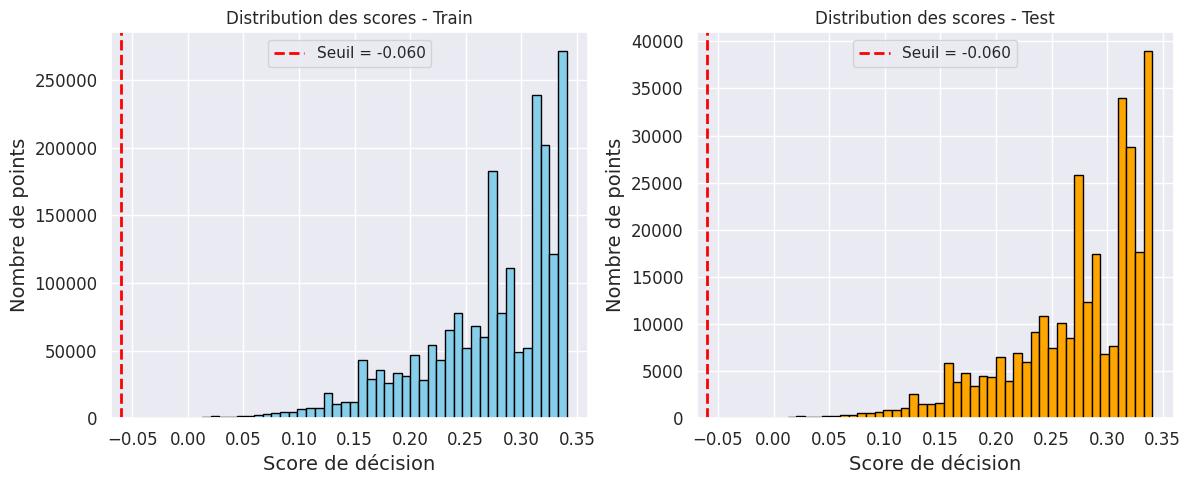


📊 Statistiques des scores:
   Train - Mean: 0.271862, Std: 0.061897, Min: -0.049719
   Test  - Mean: 0.273337, Std: 0.060848, Min: -0.049719

✅ Aucune anomalie détectée dans le test ! (toutes les données sont similaires au train)


In [61]:
print("\n🌳 Entraînement Isolation Forest (train uniquement normal)...")

# Initialisation
# ⚠️ contamination très faible car train = 100% normal
iso_forest = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination=0.0001,  # ✅ 0.01% au lieu de 'auto' (qui donne 10%)
    random_state=42,
    n_jobs=-1
)

# Entraînement
iso_forest.fit(X_train_scaled)
print("✅ Isolation Forest entraîné")

# Scores de décision
train_scores = iso_forest.decision_function(X_train_scaled)
test_scores = iso_forest.decision_function(X_test_scaled)

# 🎯 MÉTHODE 1 : Utiliser un seuil basé sur le minimum du train
# Comme le train est 100% normal, tout ce qui est en dessous du min est une anomalie
train_threshold = train_scores.min() - 0.01  # Légèrement sous le minimum

# Appliquer ce seuil pour les prédictions
train_predictions = (train_scores < train_threshold).astype(int)
train_predictions = np.where(train_predictions == 1, -1, 1)  # -1 = anomalie, 1 = normal

test_predictions = (test_scores < train_threshold).astype(int)
test_predictions = np.where(test_predictions == 1, -1, 1)

# 📊 Statistiques
train_anomalies = (train_predictions == -1).sum()
test_anomalies = (test_predictions == -1).sum()

print(f"\n📊 Résultats avec seuil basé sur min(train):")
print(f"   Seuil utilisé: {train_threshold:.6f}")
print(f"   Train anomalies: {train_anomalies}/{len(train_predictions)} ({train_anomalies/len(train_predictions)*100:.2f}%)")
print(f"   Test anomalies: {test_anomalies}/{len(test_predictions)} ({test_anomalies/len(test_predictions)*100:.2f}%)")

# 🔍 Visualisation de la distribution des scores
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(train_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(train_threshold, color='red', linestyle='--', linewidth=2, label=f'Seuil = {train_threshold:.3f}')
plt.title("Distribution des scores - Train")
plt.xlabel("Score de décision")
plt.ylabel("Nombre de points")
plt.legend()

plt.subplot(1,2,2)
plt.hist(test_scores, bins=50, color='orange', edgecolor='black')
plt.axvline(train_threshold, color='red', linestyle='--', linewidth=2, label=f'Seuil = {train_threshold:.3f}')
plt.title("Distribution des scores - Test")
plt.xlabel("Score de décision")
plt.ylabel("Nombre de points")
plt.legend()

plt.tight_layout()
plt.show()

# 📊 Comparaison des distributions
print(f"\n📊 Statistiques des scores:")
print(f"   Train - Mean: {train_scores.mean():.6f}, Std: {train_scores.std():.6f}, Min: {train_scores.min():.6f}")
print(f"   Test  - Mean: {test_scores.mean():.6f}, Std: {test_scores.std():.6f}, Min: {test_scores.min():.6f}")

# 🎯 Si le test a des scores < seuil, ce sont de vraies anomalies
if test_anomalies > 0:
    print(f"\n⚠️ {test_anomalies} anomalies détectées dans le test (scores < {train_threshold:.6f})")
else:
    print(f"\n✅ Aucune anomalie détectée dans le test ! (toutes les données sont similaires au train)")


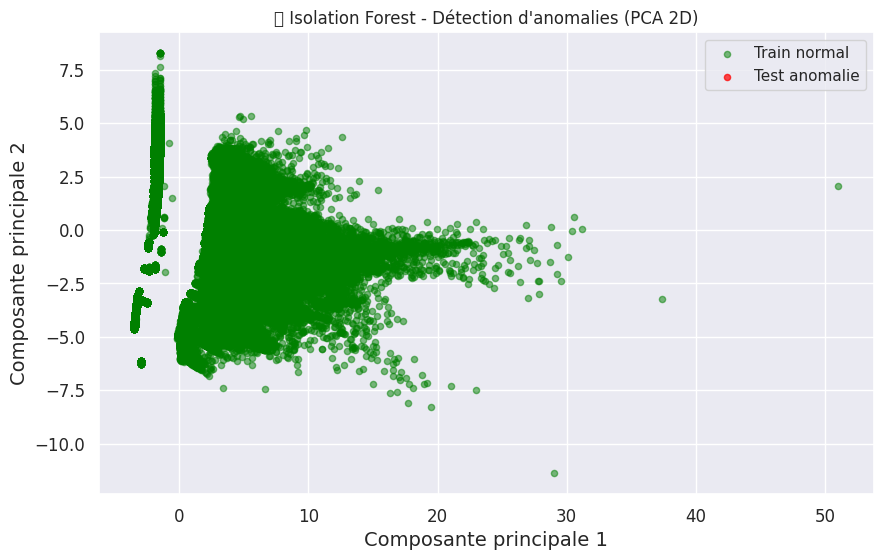

In [62]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 🔹 Réduction PCA à 2 dimensions
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)

# 🔹 Création du masque anomalies
train_anomalies_mask = np.zeros(len(X_train_scaled), dtype=bool)  # train = tout normal
test_anomalies_mask = test_scores < train_threshold

# 🔹 Visualisation
plt.figure(figsize=(10,6))

# Train normal
plt.scatter(X_train_2d[:,0], X_train_2d[:,1],
            c='green', alpha=0.5, s=20, label='Train normal')

# # Test normal
# plt.scatter(X_test_2d[~test_anomalies_mask,0], X_test_2d[~test_anomalies_mask,1],
#             c='blue', alpha=0.5, s=20, label='Test normal')

# Test anomalies
plt.scatter(X_test_2d[test_anomalies_mask,0], X_test_2d[test_anomalies_mask,1],
            c='red', alpha=0.7, s=20, label='Test anomalie')

plt.title("🌳 Isolation Forest - Détection d'anomalies (PCA 2D)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.grid(True)
plt.show()


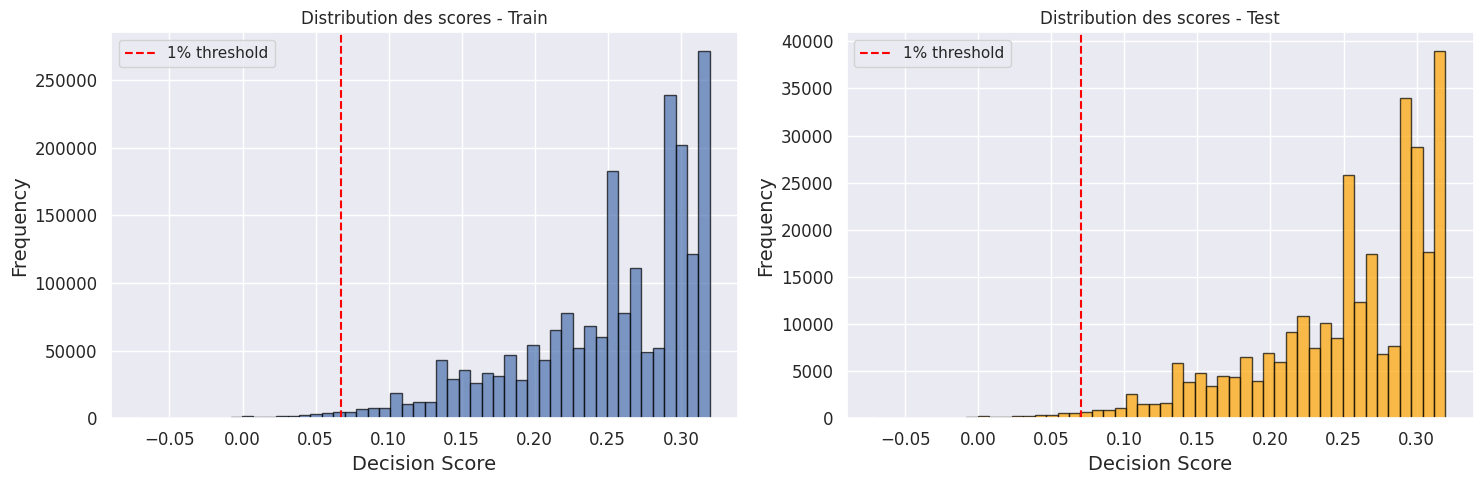

In [52]:
# Visualisation de la distribution des scores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(train_scores, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(np.percentile(train_scores, 1), color='red', linestyle='--', label='1% threshold')
axes[0].set_title('Distribution des scores - Train')
axes[0].set_xlabel('Decision Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(test_scores, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(np.percentile(test_scores, 1), color='red', linestyle='--', label='1% threshold')
axes[1].set_title('Distribution des scores - Test')
axes[1].set_xlabel('Decision Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. SUPERVISED MODELS (si labels disponibles)

In [53]:
if y_train_encoded is not None:
    print("\n🤖 Entraînement des modèles supervisés...")
    
    # KNN
    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(X_tr, y_tr)
    
    # Logistic Regression
    lgr = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
    lgr.fit(X_tr, y_tr)
    
    # Naive Bayes
    bnb = BernoulliNB()
    bnb.fit(X_tr, y_tr)
    
    # Decision Tree
    dtc = tree.DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=10)
    dtc.fit(X_tr, y_tr)
    
    # Random Forest
    rfc_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rfc_model.fit(X_tr, y_tr)
    
    print("✅ 5 modèles entraînés")
    
    models = [
        ('KNN', knn),
        ('Logistic Regression', lgr),
        ('Naive Bayes', bnb),
        ('Decision Tree', dtc),
        ('Random Forest', rfc_model)
    ]
else:
    print("\n⚠️ Mode non supervisé : pas d'entraînement de modèles supervisés")
    models = []


⚠️ Mode non supervisé : pas d'entraînement de modèles supervisés


## 11. MODEL EVALUATION

In [54]:
if len(models) > 0 and y_val is not None:
    print("\n" + "="*80)
    print("📊 ÉVALUATION DES MODÈLES SUR VALIDATION SET")
    print("="*80)
    
    results = []
    
    for name, model in models:
        # Prédictions
        y_pred = model.predict(X_val)
        
        # Métriques
        accuracy = metrics.accuracy_score(y_val, y_pred)
        precision = metrics.precision_score(y_val, y_pred, average='weighted', zero_division=0)
        recall = metrics.recall_score(y_val, y_pred, average='weighted', zero_division=0)
        f1 = metrics.f1_score(y_val, y_pred, average='weighted', zero_division=0)
        
        results.append({
            'Model': name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })
        
        print(f"\n{'='*80}")
        print(f"{name}")
        print(f"{'='*80}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"\nClassification Report:")
        print(metrics.classification_report(y_val, y_pred, target_names=le.classes_, zero_division=0))
        print(f"\nConfusion Matrix:")
        print(metrics.confusion_matrix(y_val, y_pred))
    
    # Comparaison des modèles
    results_df = pd.DataFrame(results)
    print(f"\n{'='*80}")
    print("📊 COMPARAISON DES MODÈLES")
    print(f"{'='*80}")
    print(results_df.to_string(index=False))
    
    # Meilleur modèle
    best_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
    print(f"\n🏆 Meilleur modèle: {best_model}")

## 12. TEST SET EVALUATION

In [55]:
if len(models) > 0 and y_test_encoded is not None:
    print("\n" + "="*80)
    print("📊 ÉVALUATION SUR TEST SET")
    print("="*80)
    
    for name, model in models:
        y_pred = model.predict(X_test_scaled)
        accuracy = metrics.accuracy_score(y_test_encoded, y_pred)
        
        print(f"\n{name}:")
        print(f"  Accuracy: {accuracy:.4f}")
        print(metrics.classification_report(y_test_encoded, y_pred, 
                                           target_names=le.classes_, zero_division=0))

## 13. SAVE MODELS

In [56]:
# Sauvegarder Isolation Forest (méthode principale)
print("\n💾 Sauvegarde des modèles...")

# Config de preprocessing
config = {
    'BASE_FEATURES': BASE_FEATURES,
    'DERIVED_FEATURES': DERIVED_FEATURES,
    'FEATURES': ALL_FEATURES,
    'log_cols': log_cols,
    'cols_to_replace': ['flowDurationMs', 'totalPacketsUpstream', 
                        'totalPacketsDownstream', 'interArrivalTimeMean'],
    'scaler': scaler
}

with open('preprocessing_config.pkl', 'wb') as f:
    pickle.dump(config, f)
print("   ✅ preprocessing_config.pkl")

# Isolation Forest
with open('IDS_Stage1_Detector.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)
print("   ✅ IDS_Stage1_Detector.pkl (Isolation Forest)")

# Sauvegarder le meilleur modèle supervisé si disponible
if len(models) > 0:
    best_model_obj = [m for n, m in models if n == best_model][0]
    with open(f'IDS_Stage1_{best_model.replace(" ", "_")}.pkl', 'wb') as f:
        pickle.dump(best_model_obj, f)
    print(f"   ✅ IDS_Stage1_{best_model.replace(' ', '_')}.pkl")

print("\n✅ Tous les modèles sont sauvegardés!")


💾 Sauvegarde des modèles...
   ✅ preprocessing_config.pkl
   ✅ IDS_Stage1_Detector.pkl (Isolation Forest)

✅ Tous les modèles sont sauvegardés!


## 14. EXPORT RESULTS

In [57]:
# Ajouter les prédictions au test set
test_results = test_processed.copy()
test_results['iso_forest_prediction'] = test_predictions
test_results['iso_forest_score'] = test_scores
test_results['iso_forest_label'] = test_predictions
test_results['iso_forest_label'] = test_results['iso_forest_label'].map(
    {-1: 'ANOMALY', 1: 'NORMAL'}
)

# Exporter
output_file = TEST_PATH.replace('.csv', '_predictions.csv')
test_results.to_csv(output_file, index=False)
print(f"\n💾 Résultats exportés: {output_file}")

# Top anomalies
anomalies = test_results[test_results['iso_forest_label'] == 'ANOMALY'].sort_values('iso_forest_score')
if len(anomalies) > 0:
    print(f"\n🚨 Top 10 anomalies détectées:")
    cols = ['srcIp', 'dstIp', 'protocol', 'bytes', 'packets', 'flowDurationMs', 'iso_forest_score']
    available_cols = [c for c in cols if c in anomalies.columns]
    print(anomalies[available_cols].head(10).to_string(index=False))


💾 Résultats exportés: data/vertx_realtime_normaltraffic_20260203_predictions.csv

🚨 Top 10 anomalies détectées:
protocol  bytes  packets  flowDurationMs  iso_forest_score
     TCP   1133       10       6269420.0         -0.070579
     TCP   1799       12        129540.0         -0.047349
     TCP   3963       14         71781.0         -0.043990
     TCP   3621       17        102826.0         -0.042033
     TCP   4152       18         32580.0         -0.033350
     TCP   2113       14         46775.0         -0.032535
     TCP   3313       12         24975.0         -0.032462
     TCP 143936        8      10535774.0         -0.032456
     TCP   1694       12         20886.0         -0.032088
     TCP   2047       13         21376.0         -0.027071


## ✅ RÉSUMÉ FINAL

In [58]:
print("\n" + "="*80)
print("🎉 PIPELINE COMPLET TERMINÉ")
print("="*80)
print(f"\n📊 Données:")
print(f"   - Train: {len(train_processed)} flows")
print(f"   - Test: {len(test_processed)} flows")
print(f"   - Features: {len(ALL_FEATURES)}")
print(f"\n🌳 Isolation Forest:")
print(f"   - Anomalies train: {train_anomalies} ({train_anomalies/len(train_predictions)*100:.2f}%)")
print(f"   - Anomalies test: {test_anomalies} ({test_anomalies/len(test_predictions)*100:.2f}%)")
if len(models) > 0:
    print(f"\n🤖 Modèles supervisés:")
    print(f"   - Meilleur modèle: {best_model}")
    print(f"   - F1-Score: {results_df.loc[results_df['Model']==best_model, 'F1-Score'].values[0]:.4f}")
print("\n💾 Fichiers générés:")
print("   - preprocessing_config.pkl")
print("   - IDS_Stage1_Detector.pkl")
print(f"   - {output_file}")
print("\n✅ Utilisez IDS_stage1_test.py pour tester le modèle!")
print("="*80)


🎉 PIPELINE COMPLET TERMINÉ

📊 Données:
   - Train: 2100808 flows
   - Test: 299076 flows
   - Features: 37

🌳 Isolation Forest:
   - Anomalies train: 258943 (12.33%)
   - Anomalies test: 2596 (0.87%)

💾 Fichiers générés:
   - preprocessing_config.pkl
   - IDS_Stage1_Detector.pkl
   - data/vertx_realtime_normaltraffic_20260203_predictions.csv

✅ Utilisez IDS_stage1_test.py pour tester le modèle!
